# P02: 构建 RSSM 动力学模型

在合成像素轨迹上训练并对比 GRU、MDN-RNN 和 RSSM 三种动力学模型。本 notebook 的重点在于对比，而非追求排行榜成绩：GRU 是最简单的基线，MDN-RNN 引入预测不确定性，RSSM 则通过潜在随机状态实现世界模型风格的 rollout。

**前置条件**：P01 生成的 `vae_encoder.pt` 权重文件（如有）；否则 notebook 会使用随机初始化的编码器继续运行，但此时 rollout 对比结果仅供参考，意义有限。本 notebook 将训练动力学模型，并将 RSSM 保存为 `rssm.pt`，供 P03 和 P04 使用。

> Notebook 源文件: [p02_rssm_dynamics.ipynb](https://github.com/datawhalechina/learn-world-model/blob/main/docs/zh/projects/p02_rssm_dynamics.ipynb)

In [1]:
%%bash
# Install dependencies for a fresh environment.
if command -v rocm-smi >/dev/null || [ -d /opt/rocm ]; then
  pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm7.2
  pip install matplotlib numpy
else
  pip install torch torchvision matplotlib numpy
fi


## 1. 环境准备

构建冻结编码器、合成轨迹数据集及潜在数据集。

In [ ]:
import math
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 让 Colab 和新环境优先使用支持中文的字体，避免标题和坐标轴显示成方框。
def _configure_cjk_font():
    preferred = [
        "Noto Sans CJK SC",
        "Noto Sans SC",
        "Source Han Sans SC",
        "Microsoft YaHei",
        "SimHei",
        "PingFang SC",
        "WenQuanYi Micro Hei",
    ]
    for family in preferred:
        try:
            font_manager.findfont(family, fallback_to_default=False)
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [family] + [f for f in mpl.rcParams.get("font.sans-serif", []) if f != family]
            mpl.rcParams["axes.unicode_minus"] = False
            return family
        except Exception:
            pass

    font_path = Path.home() / ".cache" / "notebook-fonts" / "NotoSansCJKsc-Regular.otf"
    if not font_path.exists():
        try:
            import urllib.request
            font_path.parent.mkdir(parents=True, exist_ok=True)
            url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/SimplifiedChinese/NotoSansCJKsc-Regular.otf"
            urllib.request.urlretrieve(url, font_path)
        except Exception:
            font_path = None

    if font_path and font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        family = font_manager.FontProperties(fname=str(font_path)).get_name()
        mpl.rcParams["font.family"] = "sans-serif"
        mpl.rcParams["font.sans-serif"] = [family] + [f for f in preferred if f != family]
        mpl.rcParams["axes.unicode_minus"] = False
        return family

    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    mpl.rcParams["axes.unicode_minus"] = False
    return None

_CJK_FONT = _configure_cjk_font()

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'
LOAD_DEVICE = torch.device('cpu') if USE_TPU else DEVICE


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer_step(optimizer)

LATENT_DIM = 32
HIDDEN_DIM = 128
ACTION_DIM = 1
N_TRAJ     = 200
T_STEPS    = 20
IMG_SIZE   = 64

print(f'设备: {DEVICE}')
if USE_TPU:
    print('TPU 后端    : torch_xla')
print(f'LATENT_DIM={LATENT_DIM}, HIDDEN_DIM={HIDDEN_DIM}')

设备: cuda
LATENT_DIM=32, HIDDEN_DIM=128


环境准备完成后，先复用 P01 的编码器和解码器，让动力学模型和整个 world model 栈保持在同一个潜在空间里。

In [3]:
# 与 P01 兼容的 VAE 编码器和解码器

class VAEEncoder(nn.Module):
    """将 64x64 RGB 帧编码为潜在均值和对数方差。"""
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.conv = nn.Sequential(
            nn.Conv2d(3,   32,  4, stride=2, padding=1),  # 64->32
            nn.ReLU(),
            nn.Conv2d(32,  64,  4, stride=2, padding=1),  # 32->16
            nn.ReLU(),
            nn.Conv2d(64,  128, 4, stride=2, padding=1),  # 16->8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),  # 8->4
            nn.ReLU(),
        )
        self.fc_mu  = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_var = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        h = self.conv(x).reshape(x.size(0), -1)
        return self.fc_mu(h), self.fc_var(h)

    def encode(self, x):
        """从 q(z|x) 进行重参数化采样。"""
        mu, logvar = self.forward(x)
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)


class VAEDecoder(nn.Module):
    """镜像解码器：latent_dim -> 64x64 RGB，值域 [0,1]。"""
    def __init__(self, latent_dim=32):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,  3,   4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).reshape(-1, 256, 4, 4)
        return self.deconv(h)


encoder = VAEEncoder(LATENT_DIM).to(DEVICE)
decoder = VAEDecoder(LATENT_DIM).to(DEVICE)

def _load_vae_checkpoint(path):
    ckpt = torch.load(path, map_location=DEVICE)
    if 'model_state_dict' in ckpt:
        state = ckpt['model_state_dict']
        enc_state = {
            k.removeprefix('encoder.').replace('fc_log_var', 'fc_var'): v
            for k, v in state.items()
            if k.startswith('encoder.')
        }
        dec_state = {
            k.removeprefix('decoder.'): v
            for k, v in state.items()
            if k.startswith('decoder.')
        }
        encoder.load_state_dict(enc_state)
        decoder.load_state_dict(dec_state)
        return True
    if 'encoder' in ckpt and 'decoder' in ckpt:
        encoder.load_state_dict(ckpt['encoder'])
        decoder.load_state_dict(ckpt['decoder'])
        return True
    raise KeyError(f'未识别的权重文件格式: {list(ckpt.keys())[:10]}')

ckpt_path = Path('vae_encoder.pt')
try:
    _load_vae_checkpoint(ckpt_path)
    print(f'已从 {ckpt_path} 加载 VAE 权重')
except Exception as e:
    print(f'无法从 {ckpt_path} 加载 VAE 权重文件（{e}），使用随机初始化。')

VAE_CHECKPOINT_PATH = ckpt_path

encoder.eval()
decoder.eval()
for p in list(encoder.parameters()) + list(decoder.parameters()):
    p.requires_grad_(False)

print(f'编码器参数量: {sum(p.numel() for p in encoder.parameters()):,}')
print(f'解码器参数量: {sum(p.numel() for p in decoder.parameters()):,}')

已从 vae_encoder.pt 加载 VAE 权重
编码器参数量: 952,352
解码器参数量: 825,059


编码器和解码器就绪后，接下来生成合成轨迹，这些 rollouts 会成为序列模型的监督信号。

In [4]:
# 生成合成轨迹数据。

def make_trajectory(T=20, img_size=64, seed=None):
    rng = np.random.RandomState(seed)
    color = rng.rand(3).astype(np.float32)
    w  = rng.randint(10, 20)
    h  = rng.randint(10, 20)
    x  = float(rng.randint(0, img_size - w))
    y  = float(rng.randint(0, img_size - h))
    vx = float(rng.randint(-3, 4))
    vy = float(rng.randint(-3, 4))
    frames  = []
    actions = []
    for _ in range(T):
        img = np.zeros((img_size, img_size, 3), dtype=np.float32)
        x1, y1 = int(np.clip(x, 0, img_size - w)), int(np.clip(y, 0, img_size - h))
        img[y1:y1 + h, x1:x1 + w] = color
        frames.append(img)
        actions.append(int(rng.randint(0, 2)))
        x = float(np.clip(x + vx + rng.uniform(-1, 1), 0, img_size - w))
        y = float(np.clip(y + vy + rng.uniform(-1, 1), 0, img_size - h))
    obs = torch.from_numpy(np.stack(frames)).permute(0, 3, 1, 2)  # [T,3,H,W]
    act = torch.tensor(actions, dtype=torch.float32)               # [T]
    return {'obs': obs, 'actions': act}


print('正在生成 200 条合成轨迹...')
trajectories = [make_trajectory(T=T_STEPS, img_size=IMG_SIZE, seed=i) for i in range(N_TRAJ)]
print(f"每条轨迹的观测形状:     {trajectories[0]['obs'].shape}")
print(f"每条轨迹的动作形状: {trajectories[0]['actions'].shape}")

正在生成 200 条合成轨迹...
每条轨迹的观测形状:     torch.Size([20, 3, 64, 64])
每条轨迹的动作形状: torch.Size([20])


轨迹数据构建好后，把每个观测编码成 z，这样后面的模块就能直接在潜在序列上学习动力学。

In [5]:
# 将观测编码为潜在序列 z [N, T, 32]

print('正在编码观测...')
latent_list = []
with torch.no_grad():
    for traj in trajectories:
        obs = traj['obs'].to(DEVICE)      # [T,3,H,W]
        z   = encoder.encode(obs)         # [T, latent_dim]
        latent_list.append(z.cpu())

Z_all = torch.stack(latent_list, dim=0)                                     # [N,T,32]
A_all = torch.stack([t['actions'] for t in trajectories], dim=0)            # [N,T]

# 训练/测试划分
N_TRAIN = 180
Z_train, A_train = Z_all[:N_TRAIN].to(DEVICE), A_all[:N_TRAIN].to(DEVICE)
Z_test,  A_test  = Z_all[N_TRAIN:].to(DEVICE), A_all[N_TRAIN:].to(DEVICE)

print(f'Z_all 形状: {Z_all.shape}  (N, T, latent_dim)')
print(f'训练集: {N_TRAIN} 条轨迹 | 测试集: {N_TRAJ - N_TRAIN} 条轨迹')

正在编码观测...
Z_all 形状: torch.Size([200, 20, 32])  (N, T, latent_dim)
训练集: 180 条轨迹 | 测试集: 20 条轨迹


## 2. 动力学模型

从最简单的 GRU 基线出发，依次加入混合密度输出和 RSSM 潜在状态。

In [6]:
class GRUDynamics(nn.Module):
    """GRU 动力学模型，hidden_dim=128，输入为 (latent_dim+action_dim)，输出为 latent_dim。
    接受 (z_t, a_t) 作为输入，经 GRU 更新后预测 z_{t+1}。
    """
    def __init__(self, latent_dim=32, action_dim=1, hidden_dim=128):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gru    = nn.GRUCell(latent_dim + action_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z_seq, a_seq):
        """z_seq [B,T,D], a_seq [B,T] -> pred_z [B,T-1,D]，对应步骤 1..T。"""
        B, T, _ = z_seq.shape
        h = torch.zeros(B, self.hidden_dim, device=z_seq.device)
        preds = []
        for t in range(T - 1):
            inp = torch.cat([z_seq[:, t], a_seq[:, t].unsqueeze(-1)], dim=-1)
            h   = self.gru(inp, h)
            preds.append(self.output(h))
        return torch.stack(preds, dim=1)  # [B, T-1, D]

    def rollout(self, z0, a_seq):
        """从 z0 [1,D] 开始，按 a_seq 进行开环 rollout。
        返回 [1, steps+1, D]（包含 z0）。
        """
        z = z0
        h = torch.zeros(1, self.hidden_dim, device=z0.device)
        zs = [z]
        for a in a_seq:
            inp = torch.cat([z, a.view(1, 1)], dim=-1)
            h   = self.gru(inp, h)
            z   = self.output(h)
            zs.append(z)
        return torch.stack(zs, dim=1)  # [1, steps+1, D]


gru_model = GRUDynamics(LATENT_DIM, ACTION_DIM, HIDDEN_DIM).to(DEVICE)
print(f'GRUDynamics 参数量: {sum(p.numel() for p in gru_model.parameters()):,}')

GRUDynamics 参数量: 66,720


有了普通 GRU 基线以后，再补上 MDN-RNN，用多峰分布去描述单点预测无法覆盖的不确定性。

In [7]:
class MDNRNN(nn.Module):
    """GRU + MDN 输出头，对 z_{t+1} 预测由 3 个高斯分量组成的混合分布。
    MDN 损失：混合分布的负对数似然。
    """
    def __init__(self, latent_dim=32, action_dim=1, hidden_dim=128, n_mix=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.n_mix  = n_mix
        self.gru    = nn.GRUCell(latent_dim + action_dim, hidden_dim)
        # logits (K), mu (K*D), log_sigma (K*D)
        self.mdn_head = nn.Linear(hidden_dim, n_mix + 2 * n_mix * latent_dim)

    def _split(self, out):
        K, D = self.n_mix, self.latent_dim
        logits = out[..., :K]
        mu     = out[..., K:K + K * D].reshape(*out.shape[:-1], K, D)
        log_s  = out[..., K + K * D:].reshape(*out.shape[:-1], K, D)
        return logits, mu, log_s

    def forward(self, z_seq, a_seq):
        """返回 (logits, mu, log_sigma)，各自形状为 [B, T-1, ...]，用于计算 MDN 损失。"""
        B, T, _ = z_seq.shape
        h = torch.zeros(B, self.hidden_dim, device=z_seq.device)
        all_logits, all_mu, all_ls = [], [], []
        for t in range(T - 1):
            inp = torch.cat([z_seq[:, t], a_seq[:, t].unsqueeze(-1)], dim=-1)
            h   = self.gru(inp, h)
            lg, mu, ls = self._split(self.mdn_head(h))
            all_logits.append(lg)
            all_mu.append(mu)
            all_ls.append(ls)
        return (
            torch.stack(all_logits, dim=1),
            torch.stack(all_mu,     dim=1),
            torch.stack(all_ls,     dim=1),
        )

    def mdn_loss(self, logits, mu, log_sigma, target):
        """混合分布的负对数似然损失。
        logits [B,T,K], mu [B,T,K,D], log_sigma [B,T,K,D], target [B,T,D]。
        """
        B, T, K, D = mu.shape
        tgt = target.unsqueeze(2).expand_as(mu)  # [B,T,K,D]
        sigma = log_sigma.exp().clamp(min=1e-4)
        log_p = -0.5 * (((tgt - mu) / sigma) ** 2 + 2 * log_sigma
                        + math.log(2 * math.pi))
        log_p  = log_p.sum(-1)                          # [B,T,K]
        log_pi = F.log_softmax(logits, dim=-1)          # [B,T,K]
        return -torch.logsumexp(log_pi + log_p, dim=-1).mean()

    def rollout(self, z0, a_seq):
        """使用概率最高的混合分量进行开环 rollout。
        返回 [1, steps+1, D]。
        """
        z  = z0
        h  = torch.zeros(1, self.hidden_dim, device=z0.device)
        zs = [z]
        for a in a_seq:
            inp = torch.cat([z, a.view(1, 1)], dim=-1)
            h   = self.gru(inp, h)
            lg, mu, _ = self._split(self.mdn_head(h))
            k = lg[0].argmax().item()
            z = mu[0, k].unsqueeze(0)   # [1, D]
            zs.append(z)
        return torch.stack(zs, dim=1)


mdn_model = MDNRNN(LATENT_DIM, ACTION_DIM, HIDDEN_DIM, n_mix=3).to(DEVICE)
print(f'MDNRNN 参数量: {sum(p.numel() for p in mdn_model.parameters()):,}')

MDNRNN 参数量: 87,747


两个基线都定义完后，接着实现 RSSM，作为我们要对比的结构化 latent-state 模型。

In [8]:
class RSSM(nn.Module):
    """循环状态空间模型（RSSM）。
    确定性路径：h_t = GRU(h_{t-1}, z_{t-1}, a_{t-1})
    随机先验：   z_t ~ N(mu_prior(h_t), sigma_prior(h_t))
    随机后验：   z_t ~ N(mu_post(h_t, o_t), sigma_post(h_t, o_t))
    训练目标：   ELBO = 重建损失 + KL(后验 || 先验)
    hidden_dim=128, latent_dim=32
    """
    def __init__(self, latent_dim=32, action_dim=1, hidden_dim=128):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        # 确定性循环
        self.gru = nn.GRUCell(latent_dim + action_dim, hidden_dim)

        # 先验网络：h_t -> (mu, logvar)
        self.prior_net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )

        # 后验网络：(h_t, o_t) -> (mu, logvar)，o_t 为编码后的观测
        self.post_net = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )

        # 重建头：z -> 预测 z（潜在重建目标）
        self.recon = nn.Linear(latent_dim, latent_dim)

    def _rsample(self, mu, logvar):
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)

    def forward(self, z_seq, a_seq):
        """计算整条轨迹的 ELBO 损失。
        z_seq [B,T,D], a_seq [B,T]。
        返回标量 ELBO 损失。
        """
        B, T, D = z_seq.shape
        h = torch.zeros(B, self.hidden_dim, device=z_seq.device)
        z = torch.zeros(B, D, device=z_seq.device)
        recon_loss = z_seq.new_zeros(())
        kl_loss    = z_seq.new_zeros(())
        for t in range(T):
            inp = torch.cat([z, a_seq[:, t].unsqueeze(-1)], dim=-1)
            h   = self.gru(inp, h)

            # 先验
            pr   = self.prior_net(h)
            mu_pr, lv_pr = pr.chunk(2, dim=-1)

            # 以观测潜在向量 o_t = z_seq[:, t] 为条件的后验
            po   = self.post_net(torch.cat([h, z_seq[:, t]], dim=-1))
            mu_po, lv_po = po.chunk(2, dim=-1)

            z = self._rsample(mu_po, lv_po)

            # 重建损失：预测观测潜在向量
            recon_loss = recon_loss + F.mse_loss(self.recon(z), z_seq[:, t])

            # KL(后验 || 先验)
            kl = 0.5 * (
                lv_pr - lv_po
                + (lv_po.exp() + (mu_po - mu_pr) ** 2) / lv_pr.exp().clamp(min=1e-4)
                - 1
            )
            kl_loss = kl_loss + kl.mean()

        return (recon_loss + kl_loss) / T

    def rollout(self, z0, a_seq):
        """仅使用先验（不观测）进行开环 rollout。
        返回 [1, steps+1, D]。
        """
        z  = z0
        h  = torch.zeros(1, self.hidden_dim, device=z0.device)
        zs = [z]
        for a in a_seq:
            inp = torch.cat([z, a.view(1, 1)], dim=-1)
            h   = self.gru(inp, h)
            pr  = self.prior_net(h)
            mu, _ = pr.chunk(2, dim=-1)
            z  = mu  # 确定性 rollout 使用先验均值
            zs.append(z)
        return torch.stack(zs, dim=1)


rssm_model = RSSM(LATENT_DIM, ACTION_DIM, HIDDEN_DIM).to(DEVICE)
print(f'RSSM 参数量: {sum(p.numel() for p in rssm_model.parameters()):,}')

RSSM 参数量: 117,280


## 3. 训练

三个模型均在 180 条训练轨迹上使用 Adam（lr=1e-3）训练 20 轮。
各模型的损失函数如下：
- GRU：预测 z 与真实 z 之间的 MSE
- MDN-RNN：高斯混合分布的负对数似然
- RSSM：ELBO = z 的 MSE 重建损失 + KL 散度

In [9]:
EPOCHS = 20
BATCH  = 32
LR     = 1e-3

opt_gru  = torch.optim.Adam(gru_model.parameters(),  lr=LR)
opt_mdn  = torch.optim.Adam(mdn_model.parameters(),  lr=LR)
opt_rssm = torch.optim.Adam(rssm_model.parameters(), lr=LR)


def run_epoch(model, optimizer, Z, A, loss_fn):
    model.train()
    N   = Z.shape[0]
    idx = torch.randperm(N)
    total, nb = 0.0, 0
    for s in range(0, N, BATCH):
        bi  = idx[s:s + BATCH]
        zb, ab = Z[bi], A[bi]
        optimizer.zero_grad()
        loss = loss_fn(model, zb, ab)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item(); nb += 1
    return total / nb


def gru_loss(m, zb, ab):
    return F.mse_loss(m(zb, ab), zb[:, 1:])


def mdn_loss_fn(m, zb, ab):
    logits, mu, ls = m(zb, ab)
    return m.mdn_loss(logits, mu, ls, zb[:, 1:])


def rssm_loss(m, zb, ab):
    return m(zb, ab)


losses_gru, losses_mdn, losses_rssm = [], [], []

print(f'训练 3 个模型，共 {EPOCHS} 轮...')
for epoch in range(1, EPOCHS + 1):
    lg = run_epoch(gru_model,  opt_gru,  Z_train, A_train, gru_loss)
    lm = run_epoch(mdn_model,  opt_mdn,  Z_train, A_train, mdn_loss_fn)
    lr = run_epoch(rssm_model, opt_rssm, Z_train, A_train, rssm_loss)
    losses_gru.append(lg)
    losses_mdn.append(lm)
    losses_rssm.append(lr)
    if epoch % 5 == 0 or epoch == 1:
        print(f'第 {epoch:3d} 轮 | GRU: {lg:.4f} | MDN-RNN: {lm:.4f} | RSSM: {lr:.4f}')

print('训练完成。')

训练 3 个模型，共 20 轮...
第   1 轮 | GRU: 0.9952 | MDN-RNN: 45.4493 | RSSM: 1.3548
第   5 轮 | GRU: 0.7320 | MDN-RNN: 38.8799 | RSSM: 0.8381
第  10 轮 | GRU: 0.6826 | MDN-RNN: 35.0690 | RSSM: 0.7751
第  15 轮 | GRU: 0.6689 | MDN-RNN: 33.5972 | RSSM: 0.7542
第  20 轮 | GRU: 0.6605 | MDN-RNN: 32.9061 | RSSM: 0.7187
训练完成。


模型家族准备完成后，设置训练轮数，并把三个动力学版本放在一起训练。

/tmp/ipykernel_11122/1014685750.py:18: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/1014685750.py:18: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/1014685750.py:18: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/1014685750.py:18: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/1014685750.py:18: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/1014685750.py:18: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/1014685750.py:18: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAP

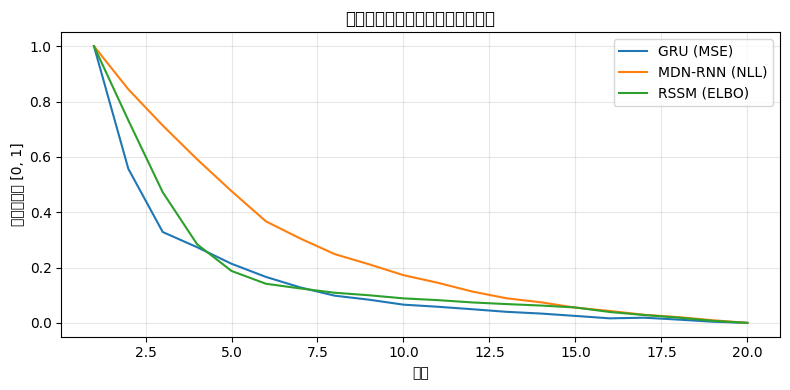

In [10]:
# 绘制归一化训练损失曲线。

def norm01(curve):
    a = np.array(curve, dtype=np.float64)
    lo, hi = a.min(), a.max()
    return (a - lo) / (hi - lo + 1e-9)

fig, ax = plt.subplots(figsize=(8, 4))
xs = np.arange(1, EPOCHS + 1)
ax.plot(xs, norm01(losses_gru),  label='GRU (MSE)',     color='tab:blue')
ax.plot(xs, norm01(losses_mdn),  label='MDN-RNN (NLL)', color='tab:orange')
ax.plot(xs, norm01(losses_rssm), label='RSSM (ELBO)',   color='tab:green')
ax.set_xlabel('轮次')
ax.set_ylabel('归一化损失 [0, 1]')
ax.set_title('训练损失曲线（归一化以便对比）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Rollout 对比

从测试轨迹的第一帧出发，三个模型各自向前推演 10 步，期间不观测未来帧。预测得到的潜在向量被解码回像素空间，以网格形式展示（3 行 x 10 列）。

In [11]:
ROLLOUT_STEPS = 10

# 使用第一条测试轨迹。
z_traj = Z_test[0]           # [T, D]
a_traj = A_test[0]           # [T]
z0     = z_traj[0].unsqueeze(0)        # [1, D]
a_seq  = a_traj[:ROLLOUT_STEPS]        # [10]

gru_model.eval()
mdn_model.eval()
rssm_model.eval()

with torch.no_grad():
    zs_gru  = gru_model.rollout(z0, a_seq).squeeze(0)    # [11, D]
    zs_mdn  = mdn_model.rollout(z0, a_seq).squeeze(0)
    zs_rssm = rssm_model.rollout(z0, a_seq).squeeze(0)

    def decode_seq(zs):
        """zs [S, D] -> numpy [S, H, W, 3]，值域 [0,1]。"""
        imgs = decoder(zs.to(DEVICE))  # [S, 3, H, W]
        return imgs.cpu().permute(0, 2, 3, 1).numpy()

    imgs_gru  = decode_seq(zs_gru)
    imgs_mdn  = decode_seq(zs_mdn)
    imgs_rssm = decode_seq(zs_rssm)
    imgs_gt   = decode_seq(z_traj[:ROLLOUT_STEPS + 1])   # 真实帧

print(f'解码后的 rollout 形状（GRU）: {imgs_gru.shape}  (steps+1, H, W, 3)')

解码后的 rollout 形状（GRU）: (11, 64, 64, 3)  (steps+1, H, W, 3)


训练完成后，下一步看 rollout，观察预测步数变长时误差如何累积。

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39588 (\N{CJK UNIFIED IDEOGRAPH-9AA4}) missing from font(s) DejaVu Sans.
  fig.canvas

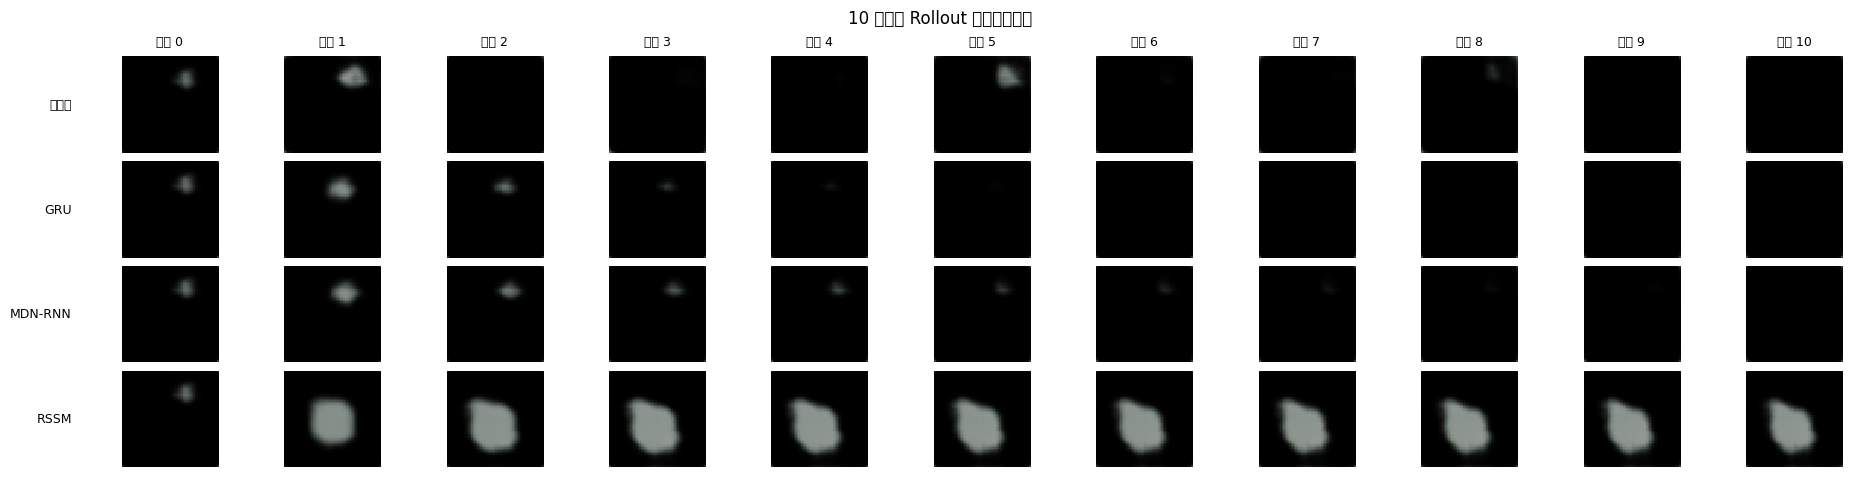

In [12]:
# 图像网格：真实帧、GRU、MDN-RNN、RSSM。
N_COLS      = ROLLOUT_STEPS + 1
row_labels  = ['真实帧', 'GRU', 'MDN-RNN', 'RSSM']
row_imgs    = [imgs_gt, imgs_gru, imgs_mdn, imgs_rssm]

fig, axes = plt.subplots(
    4,
    N_COLS,
    figsize=(N_COLS * 1.7, 4.4),
    constrained_layout=True,
)
fig.patch.set_facecolor('white')
for r, (label, imgs) in enumerate(zip(row_labels, row_imgs)):
    for c in range(N_COLS):
        ax = axes[r, c]
        ax.imshow(np.clip(imgs[c], 0, 1), interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if c == 0:
            ax.set_ylabel(
                label,
                fontsize=9,
                rotation=0,
                labelpad=36,
                va='center',
                ha='right',
            )
        if r == 0:
            ax.set_title(f'步骤 {c}', fontsize=9, pad=8)
from IPython.display import display
fig.suptitle('10 步想象 Rollout 与真实帧对比', fontsize=12, y=1.05)
display(fig)
plt.close(fig)

图像网格先给出直观感受，下面再画出逐步像素 MSE 曲线，补上定量比较。

/tmp/ipykernel_11122/2895370176.py:20: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/2895370176.py:20: UserWarning: Glyph 39588 (\N{CJK UNIFIED IDEOGRAPH-9AA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/2895370176.py:20: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/2895370176.py:20: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/2895370176.py:20: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/2895370176.py:20: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/2895370176.py:20: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAP

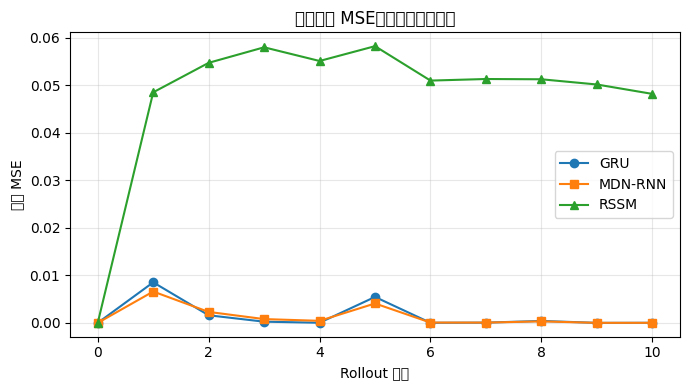

In [13]:
# 各步像素 MSE（相对于真实帧）。

def pixel_mse_per_step(pred, gt):
    return [float(((p - g) ** 2).mean()) for p, g in zip(pred, gt)]

mse_gru  = pixel_mse_per_step(imgs_gru,  imgs_gt)
mse_mdn  = pixel_mse_per_step(imgs_mdn,  imgs_gt)
mse_rssm = pixel_mse_per_step(imgs_rssm, imgs_gt)
steps_x  = list(range(N_COLS))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps_x, mse_gru,  marker='o', label='GRU',     color='tab:blue')
ax.plot(steps_x, mse_mdn,  marker='s', label='MDN-RNN', color='tab:orange')
ax.plot(steps_x, mse_rssm, marker='^', label='RSSM',    color='tab:green')
ax.set_xlabel('Rollout 步骤')
ax.set_ylabel('像素 MSE')
ax.set_title('各步像素 MSE（相对于真实帧）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 单步与多步预测误差

在保留的测试轨迹上，分别计算三个模型在预测步长 1 至 5 时的平均潜在空间 MSE。

In [14]:
MAX_H = 5


def horizon_mse(model_rollout_fn, Z, A, max_h=5):
    """计算测试集上步长 1..max_h 的平均潜在 MSE。
    model_rollout_fn(z0, a_seq) -> [1, steps+1, D]
    """
    N, T, D = Z.shape
    errs   = np.zeros(max_h)
    counts = np.zeros(max_h)
    with torch.no_grad():
        for i in range(N):
            for t0 in range(T - max_h):
                z0   = Z[i, t0].unsqueeze(0)          # [1, D]
                a_s  = A[i, t0:t0 + max_h]            # [max_h]
                zs   = model_rollout_fn(z0, a_s).squeeze(0)  # [max_h+1, D]
                for h in range(1, max_h + 1):
                    errs[h - 1]   += F.mse_loss(zs[h], Z[i, t0 + h]).item()
                    counts[h - 1] += 1
    return errs / counts


print('正在计算测试集上的步长误差...')
gru_model.eval(); mdn_model.eval(); rssm_model.eval()

err_gru  = horizon_mse(gru_model.rollout,  Z_test, A_test, MAX_H)
err_mdn  = horizon_mse(mdn_model.rollout,  Z_test, A_test, MAX_H)
err_rssm = horizon_mse(rssm_model.rollout, Z_test, A_test, MAX_H)

horizons = list(range(1, MAX_H + 1))
print('\n各步长潜在 MSE:')
print(f'{"步长":>8}  {"GRU":>10}  {"MDN-RNN":>10}  {"RSSM":>10}')
for h, (eg, em, er) in enumerate(zip(err_gru, err_mdn, err_rssm), start=1):
    print(f'{h:>8}  {eg:>10.4f}  {em:>10.4f}  {er:>10.4f}')

正在计算测试集上的步长误差...

各步长潜在 MSE:
      步长         GRU     MDN-RNN        RSSM
       1      0.7542      0.7478      1.1621
       2      0.7245      0.7130      1.3603
       3      0.7135      0.7026      1.5114
       4      0.7045      0.6952      1.5903
       5      0.7066      0.7000      1.6321


预测步数范围已经固定，下面把逐步误差画出来，方便直接比较短期和长期 rollout。

/tmp/ipykernel_11122/326792084.py:11: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/326792084.py:11: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/326792084.py:11: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/326792084.py:11: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/326792084.py:11: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/326792084.py:11: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11122/326792084.py:11: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73

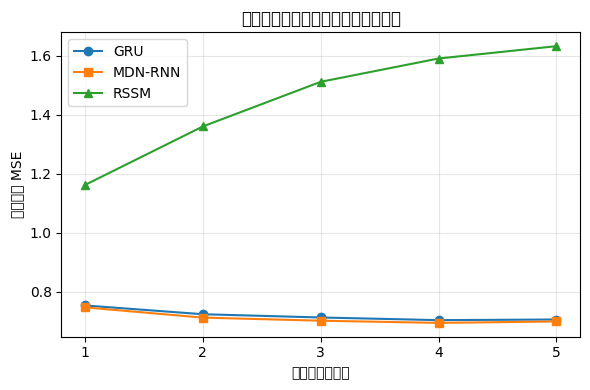

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(horizons, err_gru,  marker='o', label='GRU',     color='tab:blue')
ax.plot(horizons, err_mdn,  marker='s', label='MDN-RNN', color='tab:orange')
ax.plot(horizons, err_rssm, marker='^', label='RSSM',    color='tab:green')
ax.set_xlabel('预测步长（步）')
ax.set_ylabel('平均潜在 MSE')
ax.set_title('单步至多步预测误差（保留测试集）')
ax.set_xticks(horizons)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 保存权重文件

In [16]:
checkpoint = {
    'rssm_state_dict': rssm_model.state_dict(),
    'hidden_dim':      HIDDEN_DIM,
    'latent_dim':      LATENT_DIM,
    'action_dim':      ACTION_DIM,
    'epochs_trained':  EPOCHS,
    'final_loss':      losses_rssm[-1],
}
torch.save(checkpoint, 'rssm.pt')
print('RSSM 权重文件已保存至 rssm.pt')
print(f'  hidden_dim={HIDDEN_DIM}, latent_dim={LATENT_DIM}')
print(f'  最终 ELBO 损失: {losses_rssm[-1]:.4f}')

RSSM 权重文件已保存至 rssm.pt
  hidden_dim=128, latent_dim=32
  最终 ELBO 损失: 0.7187
